<a href="https://colab.research.google.com/github/HONGSAHUN/AI-Class/blob/main/EX_0928_car_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# car.data 분류
자동차의 가격, 유지비, 문 수, 탑승 인원, 트렁크 크기, 안전도로 구매 적합도(4등급)를 분류한다.

## 1. 파일 업로드 및 라이브러리

In [1]:
from google.colab import files
files.upload()   # car.data

Saving car.data to car.data


{'car.data': b'vhigh,vhigh,2,2,small,low,unacc\nvhigh,vhigh,2,2,small,med,unacc\nvhigh,vhigh,2,2,small,high,unacc\nvhigh,vhigh,2,2,med,low,unacc\nvhigh,vhigh,2,2,med,med,unacc\nvhigh,vhigh,2,2,med,high,unacc\nvhigh,vhigh,2,2,big,low,unacc\nvhigh,vhigh,2,2,big,med,unacc\nvhigh,vhigh,2,2,big,high,unacc\nvhigh,vhigh,2,4,small,low,unacc\nvhigh,vhigh,2,4,small,med,unacc\nvhigh,vhigh,2,4,small,high,unacc\nvhigh,vhigh,2,4,med,low,unacc\nvhigh,vhigh,2,4,med,med,unacc\nvhigh,vhigh,2,4,med,high,unacc\nvhigh,vhigh,2,4,big,low,unacc\nvhigh,vhigh,2,4,big,med,unacc\nvhigh,vhigh,2,4,big,high,unacc\nvhigh,vhigh,2,more,small,low,unacc\nvhigh,vhigh,2,more,small,med,unacc\nvhigh,vhigh,2,more,small,high,unacc\nvhigh,vhigh,2,more,med,low,unacc\nvhigh,vhigh,2,more,med,med,unacc\nvhigh,vhigh,2,more,med,high,unacc\nvhigh,vhigh,2,more,big,low,unacc\nvhigh,vhigh,2,more,big,med,unacc\nvhigh,vhigh,2,more,big,high,unacc\nvhigh,vhigh,3,2,small,low,unacc\nvhigh,vhigh,3,2,small,med,unacc\nvhigh,vhigh,3,2,small,high,u

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

In [3]:
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "KNN":      KNeighborsClassifier(),
    "SVM":      SVC(),
    "Tree":     DecisionTreeClassifier(random_state=42),
    "Forest":   RandomForestClassifier(random_state=42),
}

def compare(models, X_train, X_test, y_train, y_test):
    rows = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        rows.append({"model": name,
                     "accuracy": round(accuracy_score(y_test, pred), 3),
                     "macro F1": round(f1_score(y_test, pred, average="macro"), 3)})
    return pd.DataFrame(rows).set_index("model").sort_values("macro F1", ascending=False)

## 2. 데이터 불러오기
열 이름이 없는 파일이므로 `header=None`으로 읽고 `df.columns`로 이름을 지정한다.

In [4]:
df = pd.read_csv("car.data", header=None)
df.columns = ['price', 'maint', 'doors', 'persons', 'lug_capacity', 'safety', 'output']
print(df.shape)
df.head()

(1728, 7)


,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [5]:
print(df.isnull().sum())
print(df['output'].value_counts())

price           0
maint           0
doors           0
persons         0
lug_capacity    0
safety          0
output          0
dtype: int64
output
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


결측치는 없다. `unacc`가 약 70%를 차지하는 불균형 데이터이므로 정확도와 함께 macro F1을 확인한다.

## 3. LabelEncoder 적용
모든 열이 문자형이므로 열마다 LabelEncoder를 적용하고, 인코더는 딕셔너리에 저장한다.

In [6]:
label_encoders = {}
for column in df.columns:
    label_encoders[column] = LabelEncoder()
    df[column] = label_encoders[column].fit_transform(df[column])
    le = label_encoders[column]
    print(f"{column:<13}", dict(zip(le.classes_, range(len(le.classes_)))))

df.head()

price         {'high': 0, 'low': 1, 'med': 2, 'vhigh': 3}
maint         {'high': 0, 'low': 1, 'med': 2, 'vhigh': 3}
doors         {'2': 0, '3': 1, '4': 2, '5more': 3}
persons       {'2': 0, '4': 1, 'more': 2}
lug_capacity  {'big': 0, 'med': 1, 'small': 2}
safety        {'high': 0, 'low': 1, 'med': 2}
output        {'acc': 0, 'good': 1, 'unacc': 2, 'vgood': 3}


,price,maint,doors,persons,lug_capacity,safety,output
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


LabelEncoder는 알파벳 순으로 번호를 매기므로 `price`는 `high=0, low=1, med=2, vhigh=3`이 되어 실제 크기 순서와 다르다.

## 4. 데이터 분할 및 스케일링
스케일러는 훈련 데이터로만 학습시켜 시험 데이터의 정보가 섞이지 않게 한다.

In [7]:
X = df.drop('output', axis=1).values
y = df['output'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print(X_train_s.shape, X_test_s.shape)

(1382, 6) (346, 6)


## 5. 모델 비교

In [8]:
result_car = compare(models, X_train_s, X_test_s, y_train, y_test)
result_car

,accuracy,macro F1
model,,
Tree,0.986,0.962
Forest,0.983,0.961
KNN,0.960,0.839
SVM,0.905,0.714
Logistic,0.688,0.275


최고 모델: Tree
              precision    recall  f1-score   support

         acc       0.95      0.99      0.97        77
        good       0.93      1.00      0.97        14
       unacc       1.00      0.99      1.00       242
       vgood       1.00      0.85      0.92        13

    accuracy                           0.99       346
   macro avg       0.97      0.96      0.96       346
weighted avg       0.99      0.99      0.99       346



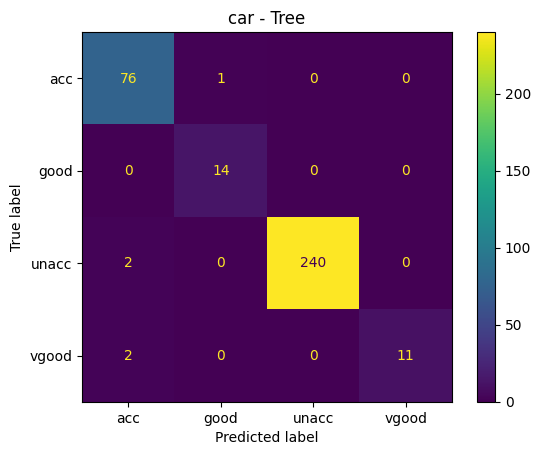

In [9]:
best_name = result_car.index[0]
pred = models[best_name].predict(X_test_s)

out_le = label_encoders['output']
print("최고 모델:", best_name)
print(classification_report(y_test, pred, target_names=out_le.classes_))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=out_le.classes_)
plt.title("car - " + best_name); plt.show()

## 6. 순서를 반영한 인코딩과 비교
입력 특성을 실제 크기 순서대로 번호를 매겨 LabelEncoder 결과와 비교한다. 정답(`output`)은 3번의 인코더를 그대로 사용한다.

In [10]:
df2 = pd.read_csv("car.data", header=None)
df2.columns = ['price', 'maint', 'doors', 'persons', 'lug_capacity', 'safety', 'output']

order = {
    'price':        {'low': 0, 'med': 1, 'high': 2, 'vhigh': 3},
    'maint':        {'low': 0, 'med': 1, 'high': 2, 'vhigh': 3},
    'doors':        {'2': 0, '3': 1, '4': 2, '5more': 3},
    'persons':      {'2': 0, '4': 1, 'more': 2},
    'lug_capacity': {'small': 0, 'med': 1, 'big': 2},
    'safety':       {'low': 0, 'med': 1, 'high': 2},
}
for col, mapping in order.items():
    df2[col] = df2[col].astype(str).map(mapping)
df2['output'] = label_encoders['output'].transform(df2['output'])

X2 = df2.drop('output', axis=1).values
y2 = df2['output'].values
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)
sc2 = StandardScaler()
X2_train_s, X2_test_s = sc2.fit_transform(X2_train), sc2.transform(X2_test)

result_order = compare(models, X2_train_s, X2_test_s, y2_train, y2_test)
pd.concat({"LabelEncoder": result_car["macro F1"], "순서 지정": result_order["macro F1"]}, axis=1)

,LabelEncoder,순서 지정
model,,
Tree,0.962,0.976
Forest,0.961,0.986
KNN,0.839,0.867
SVM,0.714,0.963
Logistic,0.275,0.673


---
# 결과 정리
- 결정 트리와 랜덤 포레스트의 성능이 가장 높았다.
- LabelEncoder는 알파벳 순으로 번호를 매겨 특성의 순서 정보를 잃는다. 순서를 반영하자 SVM의 macro F1이 0.714에서 0.963으로 올랐다. SVM과 로지스틱 회귀는 숫자의 크기와 거리를 그대로 사용하기 때문이다.
- 트리 계열은 값의 대소로 분할하므로 인코딩 방식에 따른 차이가 작았다.
- 정답 열은 순서 의미가 없으므로 LabelEncoder를 사용해도 문제가 없다.